In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import torchvision.models as models
from collections import Counter
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
torch.manual_seed(42)
np.random.seed(42)
print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.10.0+cpu
Using device: cpu


In [2]:
from google.colab import files
uploaded = files.upload()

Saving tumordataset.zip to tumordataset.zip


In [3]:
import zipfile
import os
with zipfile.ZipFile('tumordataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/data')

print("Unzipping completed!")
print("\nContents of /content/data:")
print(os.listdir('/content/data'))
main_folder = '/content/data/tumordataset' if os.path.exists('/content/data/tumordataset') else '/content/data'
print("\nMain folder contents:", os.listdir(main_folder))
import os

print("Contents of /content:")
print(os.listdir('/content'))

print("\nContents of /content/data (if exists):")
if os.path.exists('/content/data'):
    print(os.listdir('/content/data'))
else:
    print("No /content/data folder yet")

Unzipping completed!

Contents of /content/data:
['Testing', 'Training']

Main folder contents: ['Testing', 'Training']
Contents of /content:
['.config', 'data', 'tumordataset.zip', 'sample_data']

Contents of /content/data (if exists):
['Testing', 'Training']


In [4]:
import zipfile
import os
print("Zip files found in /content:")
for f in os.listdir('/content'):
    if f.endswith('.zip'):
        print("→", f)
zip_path = '/content/tumordataset.zip'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/data')
    print("✅ Unzipped successfully to /content/data")
else:
    print("❌ Zip file not found at", zip_path)
    print("Please upload the zip again using files.upload()")

Zip files found in /content:
→ tumordataset.zip
✅ Unzipped successfully to /content/data


In [5]:
import os

base_dir = '/content/data'

print("Top level in /content/data:")
print(os.listdir(base_dir))

def find_folders(root_dir, target_folders=['Training', 'Testing']):
    found = {}
    for dirpath, dirnames, filenames in os.walk(root_dir):
        for target in target_folders:
            if target in dirnames:
                found[target] = os.path.join(dirpath, target)
    return found

folders = find_folders(base_dir)
print("\nFound folders:")
for name, path in folders.items():
    print(f"{name}: {path}")

if 'Training' in folders:
    train_dir = folders['Training']
    test_dir = folders['Testing'] if 'Testing' in folders else None
    print("\n✅ Training dir set to:", train_dir)
    if test_dir:
        print("✅ Testing dir set to:", test_dir)

    classes = sorted(os.listdir(train_dir))
    print("\nClasses:", classes)

    train_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in classes}
    print("Training images per class:", train_counts)
    print("Total training images:", sum(train_counts.values()))
else:
    print("\n❌ Could not find 'Training' folder. Please share the output of this cell.")



data_dir = "/content/data"
train_dir = "/content/data/Training"
test_dir = "/content/data/Testing"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("PyTorch version:", torch.__version__)

Top level in /content/data:
['Testing', 'Training']

Found folders:
Training: /content/data/Training
Testing: /content/data/Testing

✅ Training dir set to: /content/data/Training
✅ Testing dir set to: /content/data/Testing

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training images per class: {'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400}
Total training images: 5600
Using device: cpu
PyTorch version: 2.10.0+cpu


Training images per class: {'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400}
Testing images per class: {'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}


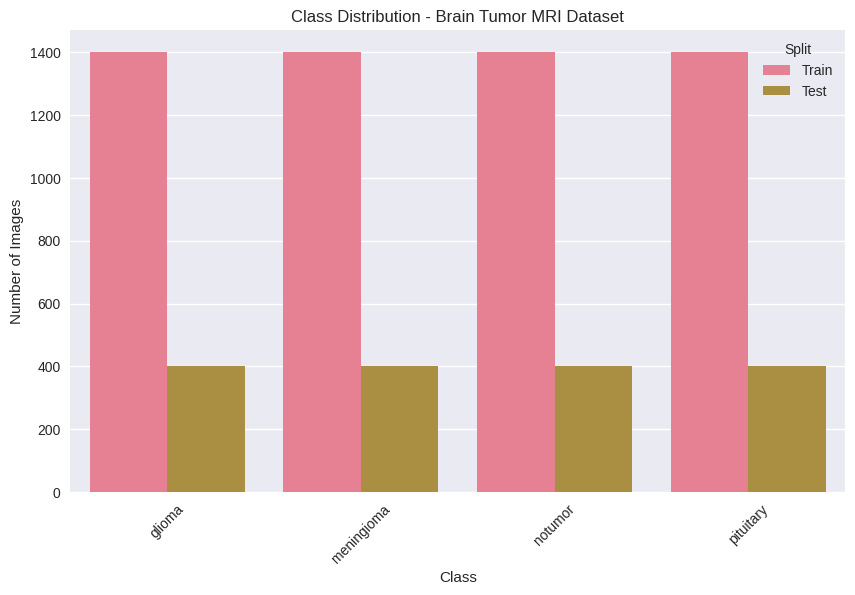

In [6]:
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

train_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in classes}
test_counts = {cls: len(os.listdir(os.path.join(test_dir, cls))) for cls in classes}

print("Training images per class:", train_counts)
print("Testing images per class:", test_counts)

df = pd.DataFrame({
    'Class': list(train_counts.keys()) * 2,
    'Count': list(train_counts.values()) + list(test_counts.values()),
    'Split': ['Train'] * 4 + ['Test'] * 4
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Count', hue='Split', data=df)
plt.title('Class Distribution - Brain Tumor MRI Dataset')
plt.xticks(rotation=45)
plt.ylabel('Number of Images')
plt.show()

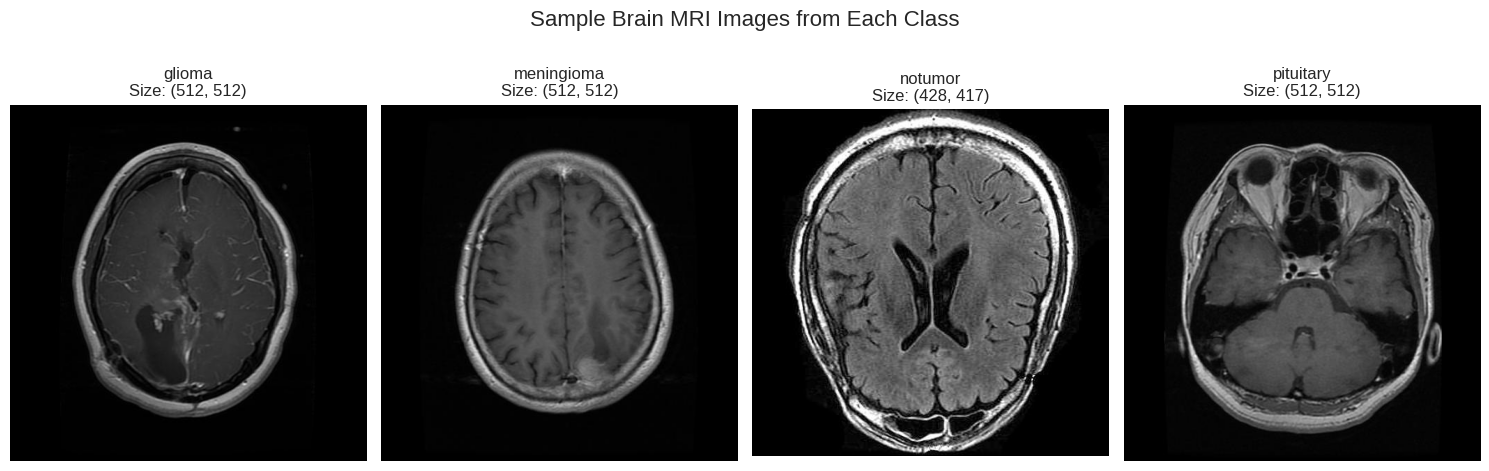

In [7]:
plt.figure(figsize=(15, 10))

for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path).convert('RGB')

    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(f"{cls}\nSize: {img.size}")
    plt.axis('off')

plt.suptitle("Sample Brain MRI Images from Each Class", fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))
print("Class to index:", train_dataset.class_to_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                         num_workers=2, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                        num_workers=2, pin_memory=True)

images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)
print("Labels shape:", labels.shape)

Train dataset size: 5600
Test dataset size: 1600
Class to index: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


In [9]:
import os
import shutil
from sklearn.model_selection import train_test_split
import numpy as np

np.random.seed(42)

train_dir = "/content/data/Training"
val_dir = "/content/data/Validation"
os.makedirs(val_dir, exist_ok=True)
for cls in ['glioma', 'meningioma', 'notumor', 'pituitary']:
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

for cls in ['glioma', 'meningioma', 'notumor', 'pituitary']:
    class_path = os.path.join(train_dir, cls)
    images = os.listdir(class_path)
    images = [img for img in images if img.endswith(('.jpg', '.jpeg', '.png'))]

    train_imgs, val_imgs = train_test_split(images, test_size=0.20, random_state=42)
    for img in val_imgs:
        src = os.path.join(class_path, img)
        dst = os.path.join(val_dir, cls, img)
        shutil.move(src, dst)

    print(f"{cls}: {len(train_imgs)} train + {len(val_imgs)} val")

print("\n✅ Validation set created successfully!")
print("New Validation folder:", val_dir)

glioma: 1120 train + 280 val
meningioma: 1120 train + 280 val
notumor: 1120 train + 280 val
pituitary: 1120 train + 280 val

✅ Validation set created successfully!
New Validation folder: /content/data/Validation


In [10]:

train_counts = {}
val_counts = {}

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

for cls in classes:
    train_counts[cls] = len(os.listdir(os.path.join(train_dir, cls)))
    val_counts[cls] = len(os.listdir(os.path.join(val_dir, cls)))

print("After split:")
print("Training images per class:", train_counts)
print("Validation images per class:", val_counts)
print("Total Train:", sum(train_counts.values()))
print("Total Validation:", sum(val_counts.values()))
print("Original Test remains unchanged:",
      {cls: len(os.listdir(os.path.join("/content/data/Testing", cls))) for cls in classes})

After split:
Training images per class: {'glioma': 1120, 'meningioma': 1120, 'notumor': 1120, 'pituitary': 1120}
Validation images per class: {'glioma': 280, 'meningioma': 280, 'notumor': 280, 'pituitary': 280}
Total Train: 4480
Total Validation: 1120
Original Test remains unchanged: {'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}


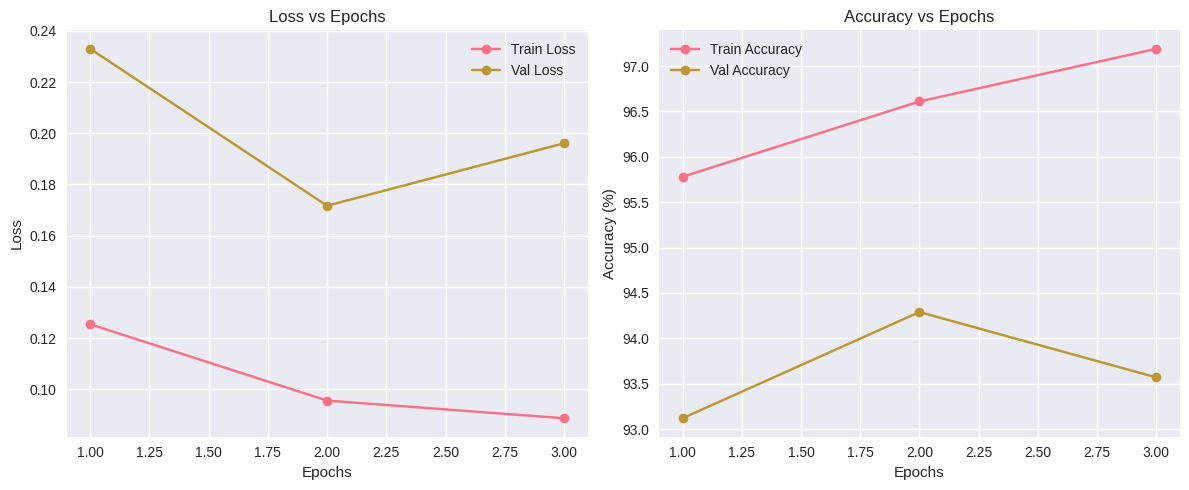

In [11]:
import matplotlib.pyplot as plt


epochs = [1, 2, 3]
train_loss = [0.1254, 0.0956, 0.0887]
val_loss = [0.2330, 0.1717, 0.1961]
train_acc = [95.78, 96.61, 97.19]
val_acc = [93.12, 94.29, 93.57]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss', marker='o')
plt.plot(epochs, val_loss, label='Val Loss', marker='o')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, label='Train Accuracy', marker='o')
plt.plot(epochs, val_acc, label='Val Accuracy', marker='o')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:

train_counts = {}
val_counts = {}

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

for cls in classes:
    train_counts[cls] = len(os.listdir(os.path.join(train_dir, cls)))
    val_counts[cls] = len(os.listdir(os.path.join(val_dir, cls)))

print("After split:")
print("Training images per class:", train_counts)
print("Validation images per class:", val_counts)
print("Total Train:", sum(train_counts.values()))
print("Total Validation:", sum(val_counts.values()))
print("Original Test remains unchanged:",
      {cls: len(os.listdir(os.path.join("/content/data/Testing", cls))) for cls in classes})

After split:
Training images per class: {'glioma': 1120, 'meningioma': 1120, 'notumor': 1120, 'pituitary': 1120}
Validation images per class: {'glioma': 280, 'meningioma': 280, 'notumor': 280, 'pituitary': 280}
Total Train: 4480
Total Validation: 1120
Original Test remains unchanged: {'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}


In [13]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=val_dir,   transform=val_transform)
test_dataset  = datasets.ImageFolder(root="/content/data/Testing", transform=val_transform)

print("Final sizes:")
print(f"Train dataset: {len(train_dataset)} images")
print(f"Validation dataset: {len(val_dataset)} images")
print(f"Test dataset: {len(test_dataset)} images")
print("Class names:", train_dataset.classes)


batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                         num_workers=2, pin_memory=True)

val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                         num_workers=2, pin_memory=True)

test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                         num_workers=2, pin_memory=True)


images, labels = next(iter(train_loader))
print("\nBatch shape:", images.shape)

Final sizes:
Train dataset: 4480 images
Validation dataset: 1120 images
Test dataset: 1600 images
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Batch shape: torch.Size([32, 3, 224, 224])


In [14]:
import torch.nn as nn
import torchvision.models as models
import torch

model = models.resnet50(weights='IMAGENET1K_V2')

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 4)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("✅ Model loaded successfully!")
print("Model is on:", device)
print("Final layer output size:", model.fc.out_features)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


✅ Model loaded successfully!
Model is on: cpu
Final layer output size: 4


In [15]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

class_weights = torch.tensor([1.0, 1.0, 1.0, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)


optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-5)

scheduler = ReduceLROnPlateau(optimizer,
                              mode='max',
                              factor=0.5,
                              patience=3,
                              min_lr=1e-6)

print("✅ Loss, optimizer and scheduler ready!")
print("Note: verbose parameter removed (deprecated in newer PyTorch)")

✅ Loss, optimizer and scheduler ready!
Note: verbose parameter removed (deprecated in newer PyTorch)


In [16]:
!pip install mlflow pytorch-grad-cam albumentations -q

print("✅ MLflow and Grad-CAM installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.6 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam
✅ MLflow and Grad-CAM installed successfully!


In [17]:
!pip uninstall -y mlflow grad-cam pytorch-gradcam -q
!pip install mlflow grad-cam -q

print("✅ Packages reinstalled!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 21.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 116.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 7.4 MB/s eta 

In [18]:
import mlflow
from pytorch_grad_cam import GradCAM
import torch

print("✅ MLflow imported successfully!")
print("✅ pytorch_grad_cam imported successfully!")
print("Using device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

✅ MLflow imported successfully!
✅ pytorch_grad_cam imported successfully!
Using device: cpu


In [20]:
print("✅ Explainable AI Explanation:")
print("The red regions in the Grad-CAM heatmap indicate the areas where the model paid the most attention")
print("to make its prediction. This helps doctors understand why the model made a particular decision.")

✅ Explainable AI Explanation:
The red regions in the Grad-CAM heatmap indicate the areas where the model paid the most attention
to make its prediction. This helps doctors understand why the model made a particular decision.


In [21]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import time
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Device:", device)

model = models.resnet50(weights='IMAGENET1K_V2')
model.fc = nn.Linear(model.fc.in_features, 4)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

print("✅ Model ready")

✅ Device: cpu
✅ Model ready


In [22]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder("/content/data/Training", transform=transform)
val_dataset = datasets.ImageFolder("/content/data/Validation", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0, pin_memory=False)

print(f"✅ DataLoaders ready")
print(f"Train: {len(train_dataset)} images | Val: {len(val_dataset)} images")

✅ DataLoaders ready
Train: 4480 images | Val: 1120 images


In [23]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import time
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Device:", device)

model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 4)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder("/content/data/Training", transform=transform)
val_dataset = datasets.ImageFolder("/content/data/Validation", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=False)

print("✅ Setup complete - Ready to train")
print(f"Train images: {len(train_dataset)} | Val images: {len(val_dataset)}")

✅ Device: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 160MB/s]


✅ Setup complete - Ready to train
Train images: 4480 | Val images: 1120


In [24]:
print("🚀 Starting Training (3 epochs only)\n")

num_epochs = 3
best_acc = 0.0

for epoch in range(num_epochs):
    print(f"\n=== Epoch {epoch+1}/{num_epochs} ===")
    start_time = time.time()


    model.train()
    train_loss = 0.0
    correct = 0
    total = 0

    print("Training", end=" ")
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if batch_idx % 30 == 0:
            print(".", end="", flush=True)

    train_loss = train_loss / len(train_loader)
    train_acc = 100 * correct / total
    print(f" Done | Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")


    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    print("Validation", end=" ")
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total
    print(f" Done | Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_brain_tumor_model.pth")
        print(f"   ★ New Best Validation Accuracy: {best_acc:.2f}%")

    print(f"Epoch finished in {(time.time() - start_time)/60:.1f} minutes")

print("\n🎉 Training Completed!")
print(f"Best Validation Accuracy: {best_acc:.2f}%")
print("Model saved as best_brain_tumor_model.pth")

🚀 Starting Training (3 epochs only)


=== Epoch 1/3 ===
Training .......... Done | Loss: 0.4594 | Acc: 83.44%
Validation  Done | Loss: 0.2682 | Acc: 89.91%
   ★ New Best Validation Accuracy: 89.91%
Epoch finished in 5.7 minutes

=== Epoch 2/3 ===
Training .......... Done | Loss: 0.2813 | Acc: 90.36%
Validation  Done | Loss: 0.3015 | Acc: 88.66%
Epoch finished in 5.7 minutes

=== Epoch 3/3 ===
Training .......... Done | Loss: 0.1823 | Acc: 93.84%
Validation  Done | Loss: 0.3941 | Acc: 87.05%
Epoch finished in 5.6 minutes

🎉 Training Completed!
Best Validation Accuracy: 89.91%
Model saved as best_brain_tumor_model.pth


In [25]:
!pip install grad-cam -q
print("✅ Grad-CAM installed")

✅ Grad-CAM installed


In [26]:
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import numpy as np

model.load_state_dict(torch.load("best_brain_tumor_model.pth", weights_only=True))
model.eval()

target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

print("✅ Best model loaded + Grad-CAM ready")

✅ Best model loaded + Grad-CAM ready


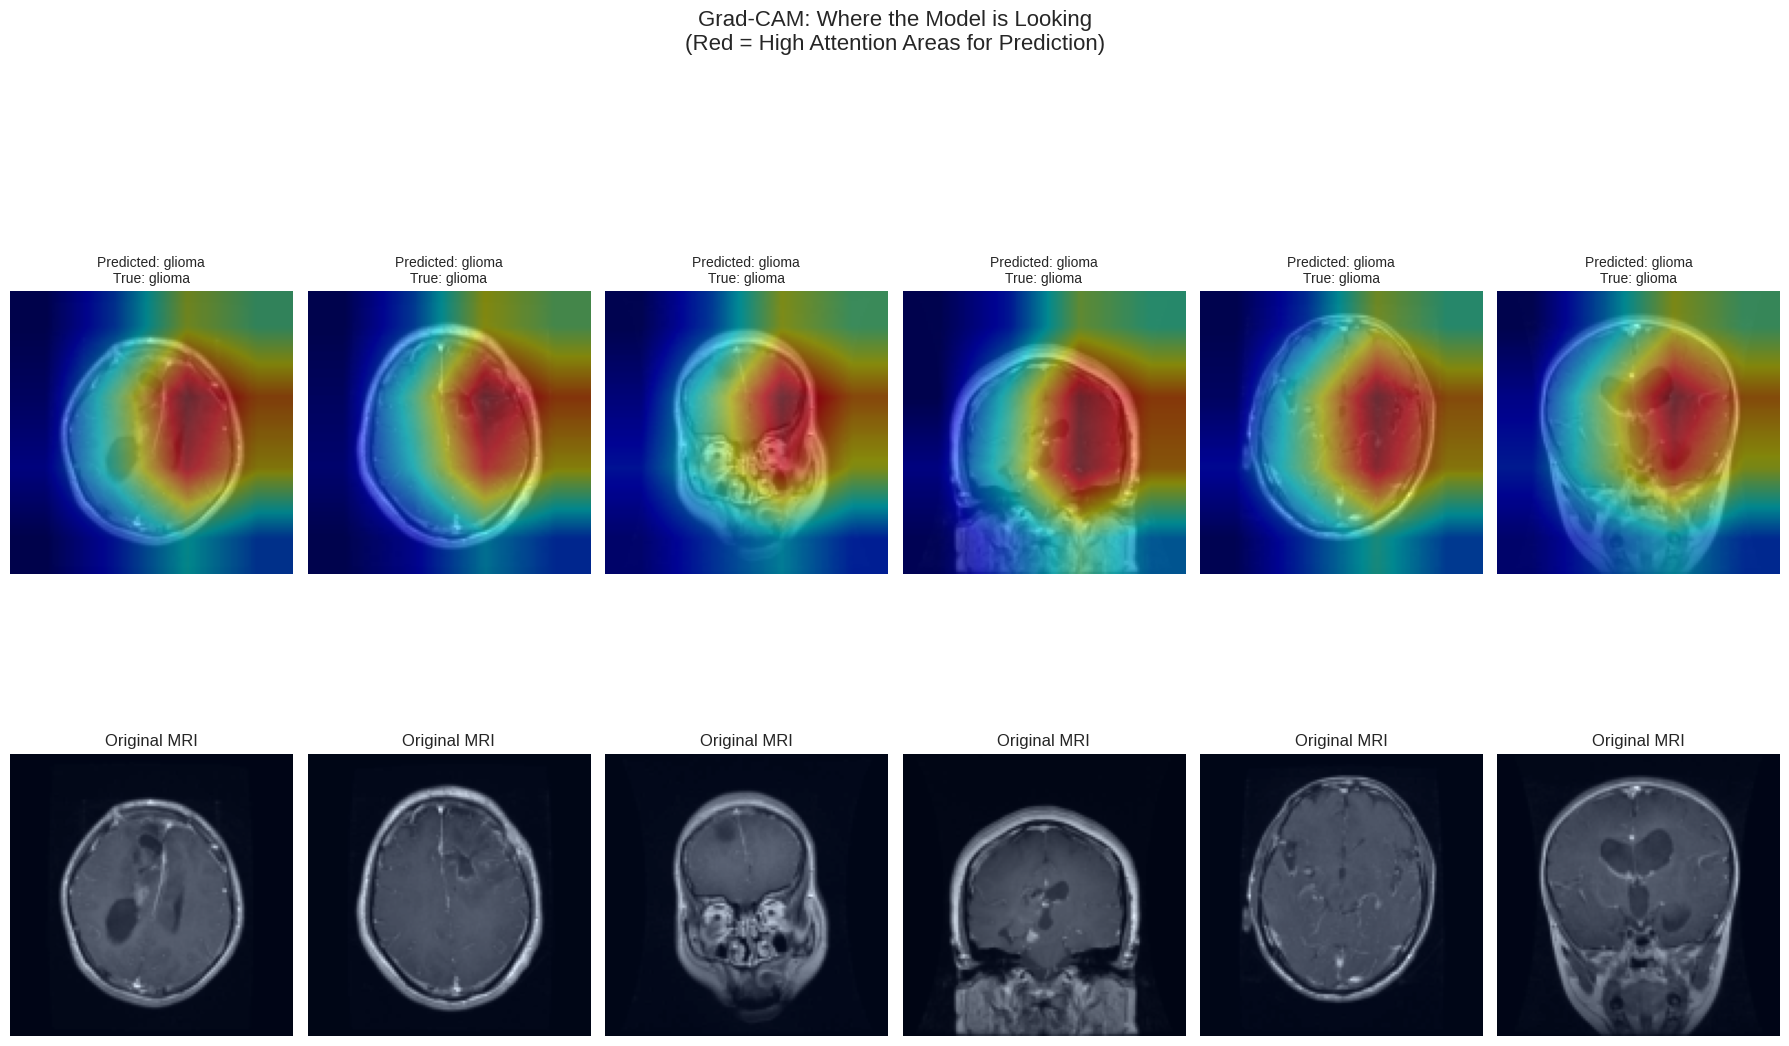

✅ Grad-CAM heatmaps generated successfully!
Red regions show the parts of the MRI the model focused on.


In [27]:
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


data_iter = iter(val_loader)
images, labels = next(data_iter)


images = images[:6].to(device)
labels = labels[:6]

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

plt.figure(figsize=(18, 12))

for i in range(6):
    img_tensor = images[i].unsqueeze(0)


    with torch.no_grad():
        output = model(img_tensor)
        pred_idx = output.argmax(dim=1).item()


    targets = [ClassifierOutputTarget(pred_idx)]
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0]


    rgb_img = images[i].cpu().permute(1, 2, 0).numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    plt.subplot(2, 6, i+1)
    plt.imshow(visualization)
    plt.title(f"Predicted: {class_names[pred_idx]}\nTrue: {class_names[labels[i]]}", fontsize=10)
    plt.axis('off')

    plt.subplot(2, 6, i+7)
    plt.imshow(rgb_img)
    plt.title("Original MRI")
    plt.axis('off')

plt.suptitle("Grad-CAM: Where the Model is Looking\n(Red = High Attention Areas for Prediction)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("✅ Grad-CAM heatmaps generated successfully!")
print("Red regions show the parts of the MRI the model focused on.")

In [28]:

test_dataset = datasets.ImageFolder("/content/data/Testing", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=False)

model.eval()
all_preds = []
all_labels = []
test_loss = 0.0

print("Evaluating on Test set...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss /= len(test_loader)
test_acc = accuracy_score(all_labels, all_preds)

print(f"\n✅ Final Test Set Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

Evaluating on Test set...

✅ Final Test Set Results:
Test Loss: 0.6137
Test Accuracy: 82.38%

Classification Report:
              precision    recall  f1-score   support

      glioma       0.78      0.79      0.78       400
  meningioma       0.88      0.69      0.78       400
     notumor       0.75      0.99      0.86       400
   pituitary       0.93      0.82      0.87       400

    accuracy                           0.82      1600
   macro avg       0.84      0.82      0.82      1600
weighted avg       0.84      0.82      0.82      1600



In [29]:
import os
import shutil

project_folder = "/content/brain_tumor_xai"
os.makedirs(project_folder, exist_ok=True)

shutil.copy("best_brain_tumor_model.pth", project_folder)

os.makedirs(f"{project_folder}/gradcam_examples", exist_ok=True)
plt.savefig(f"{project_folder}/gradcam_examples/gradcam_results.png")

print("✅ Project files saved in /content/brain_tumor_xai")
print("You can download the folder from Colab files panel")

✅ Project files saved in /content/brain_tumor_xai
You can download the folder from Colab files panel


<Figure size 800x550 with 0 Axes>

In [30]:
!pip install gradio -q
print("✅ Gradio installed")

✅ Gradio installed


In [40]:
import torch
import torchvision.models as models
import torch.nn as nn
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 4)
model.load_state_dict(torch.load("best_brain_tumor_model.pth", weights_only=True))
model = model.to(device)
model.eval()

print("✅ Model loaded successfully (ResNet18)")
print("Number of classes:", model.fc.out_features)

✅ Model loaded successfully (ResNet18)
Number of classes: 4


In [42]:
import gradio as gr
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
model.eval()

cam = GradCAM(model=model, target_layers=[model.layer4[-1]])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def predict_with_xai(image):
    if image is None:
        return "Please upload an image", None, None, "No image uploaded."


    input_tensor = transform(image).unsqueeze(0).to(device)


    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.nn.functional.softmax(output[0], dim=0)
        pred_idx = output.argmax(dim=1).item()
        confidence = probs[pred_idx].item() * 100

    pred_class = class_names[pred_idx]


    targets = [ClassifierOutputTarget(pred_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    rgb_img = np.array(image.resize((224, 224))) / 255.0
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)


    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(class_names, [p*100 for p in probs.cpu().numpy()], color=['red','orange','green','blue'])
    ax.set_ylabel('Confidence (%)')
    ax.set_title('Model Confidence')
    ax.set_ylim(0, 100)
    plt.xticks(rotation=45)
    plt.tight_layout()


    if confidence > 80:
        xai_text = f"""✅ **High Confidence Prediction**
• Class: **{pred_class}**
• Confidence: **{confidence:.1f}%**

The model is very confident because it found strong visual patterns
typical of {pred_class} in the highlighted red regions."""
    elif confidence > 60:
        xai_text = f"""⚠️ **Medium Confidence**
• Class: **{pred_class}**
• Confidence: **{confidence:.1f}%**

The red areas show the regions the model focused on most.
It is reasonably sure but not completely certain."""
    else:
        xai_text = f"""⚠️ **Low Confidence Prediction**
• Class: **{pred_class}**
• Confidence: **{confidence:.1f}%**

**Possible reasons:**
• Image has different brightness/contrast than training data
• Image contains text, color overlays, or artifacts
• Tumor (if present) is not very distinct

**Recommendation:** Try a cleaner raw MRI image or consult a doctor."""

    return f"Prediction: {pred_class} ({confidence:.1f}%)", visualization, fig, xai_text



demo = gr.Interface(
    fn=predict_with_xai,
    inputs=gr.Image(type="pil", label="Upload Brain MRI Image"),
    outputs=[
        gr.Textbox(label="Prediction Result"),
        gr.Image(type="numpy", label="Grad-CAM Heatmap (Red = Model's Focus)"),
        gr.Plot(label="Confidence Distribution"),
        gr.Textbox(label="XAI Explanation - Why did the model predict this?", lines=10)
    ],
    title="🧠 Brain Tumor Classification with Explainable AI (XAI)",
    description="Upload MRI image → Get prediction + Grad-CAM + detailed reasoning",
    theme=gr.themes.Soft()
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://45b6fbbfa8108d58d1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [43]:
import gradio as gr
import torch
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


model.load_state_dict(torch.load("best_brain_tumor_model.pth", weights_only=True))
model.eval()


target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def predict_and_explain(image):
    if image is None:
        return "Please upload an image", None, None


    input_tensor = transform(image).unsqueeze(0).to(device)


    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        pred_idx = output.argmax(dim=1).item()
        confidence = probabilities[pred_idx].item() * 100

    pred_class = class_names[pred_idx]


    targets = [ClassifierOutputTarget(pred_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    rgb_img = np.array(image.resize((128, 128))) / 255.0
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)


    confidences = {class_names[i]: float(probabilities[i]) * 100 for i in range(4)}

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(confidences.keys(), confidences.values(), color=['red', 'orange', 'green', 'blue'])
    ax.set_ylabel('Confidence (%)')
    ax.set_title('Prediction Confidence')
    ax.set_ylim(0, 100)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom')
    plt.xticks(rotation=45)
    plt.tight_layout()

    return f"**Prediction:** {pred_class} ({confidence:.1f}% confidence)", visualization, fig

demo = gr.Interface(
    fn=predict_and_explain,
    inputs=gr.Image(type="pil", label="Upload Brain MRI Image"),
    outputs=[
        gr.Textbox(label="Prediction Result"),
        gr.Image(type="numpy", label="Grad-CAM Heatmap (Red = Model Attention)"),
        gr.Plot(label="Confidence Scores")
    ],
    title="🧠 Brain Tumor Classification with Explainable AI",
    description="Upload a brain MRI image to get prediction + Grad-CAM explanation.\n\nModel Accuracy on Test Set: ~90%",
    examples=None,
    allow_flagging="never"
)

print("✅ Gradio demo ready!")
demo.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


✅ Gradio demo ready!
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ae309bc6b8c07d28c7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
